<a href="https://colab.research.google.com/github/TetianaMar-888/Python_for_ds_tasks/blob/main/2_version_Marinoshenko_Tetiana_4_1_HW_NLP_Classification.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Домашнє завдання: Побудова класифікатора сентименту на основі набору даних Tweet Sentiment Extraction

**Мета:** Провести аналіз набору даних, виконати векторизацію текстових даних за допомогою методів bag-of-words та TF-IDF, порівняти їх, побудувати класифікатор та провести аналіз помилок.

**Набір даних:**
Дані беремо з цього змагання на Kaggle: https://www.kaggle.com/competitions/tweet-sentiment-extraction/data?select=train.csv


Якщо не вдається завантажиит з Kaggle, ось тут можна - https://drive.google.com/file/d/1kfu5zCRsDHxoBZigBlGIcCieKlws02HT/view?usp=sharing

Оригінальне змагання має дещо іншу задачу, але ми будемо поки будувати саме класифікатор.

Увага! В цьому наборі завдань для простоти експериментів ми будемо спочатку робити векторизацію на всьому наборі даних, а потім розбивку на train i test. В робочих проєктах ми теж можемо використати цей підхід для швидшої побудови PoC (proof of concept). Але фінальне рішення, яке ми будемо деплоїти - треба проводити за правилом - спочатку розбивка на трейн і тест, потім пишемо обробку для трейну, навчаємо векторизатори. І потім використовуємо готові векторизатори для тесту і всіх даних на етапі передбачення (інференсу).

### Завдання 1. Завантаження та ознайомлення з набором даних

- Завантажте набір даних `train.csv` з посилання та ознайомтеся з його структурою.
- Виведіть перші 5 рядків та основну статистику: кількість записів, типи колонок, кількість пропущених значень.
- Видаліть записи, в яких є пропущені значення.



In [ ]:
from google.colab import drive
drive.mount('/content/drive/')

Mounted at /content/drive/


In [ ]:
import pandas as pd

# Завантаження даних
df = pd.read_csv('/content/drive/MyDrive/Colab Notebooks/tweet_sentiment_train.csv.zip')

In [ ]:
print( "\n" 'Кількість записів')
print(df.shape)
print( "\n" 'Типи колонок')
print(df.dtypes)
print( "\n" 'Основна статистика')
print(df.head(5))
print(df.info())
print( "\n" 'Кількість пропущених значень')
print(df.isnull().sum())
#Видаляємо записи, де є пропущені значення
df = df.dropna()


Кількість записів
(27481, 4)

Типи колонок
textID           object
text             object
selected_text    object
sentiment        object
dtype: object

Основна статистика
       textID                                               text  \
0  cb774db0d1                I`d have responded, if I were going   
1  549e992a42      Sooo SAD I will miss you here in San Diego!!!   
2  088c60f138                          my boss is bullying me...   
3  9642c003ef                     what interview! leave me alone   
4  358bd9e861   Sons of ****, why couldn`t they put them on t...   

                         selected_text sentiment  
0  I`d have responded, if I were going   neutral  
1                             Sooo SAD  negative  
2                          bullying me  negative  
3                       leave me alone  negative  
4                        Sons of ****,  negative  
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 27481 entries, 0 to 27480
Data columns (total 4 columns):
 # 

In [ ]:
print('Кількість записів після видалення')
print(df.shape)

Кількість записів після видалення
(27480, 4)


### Завдання 2. Exploratory Data Analysis

- Проведіть аналіз кількості класів та розподілу міток. Класи знаходяться в колонці `sentiment`.
- Візуалізуйте розподіл довжин текстів в символах та зробіть висновок про довжини постів: якої довжини постів найбільше, що бачите з розподілу?



In [ ]:
#Розподіл міток кількісно
df.sentiment.value_counts()

,count
sentiment,
neutral,11117
positive,8582
negative,7781


In [ ]:
#Баланс класів
df.sentiment.value_counts(normalize=True)

,proportion
sentiment,
neutral,0.404549
positive,0.312300
negative,0.283151


In [ ]:
counts = df['sentiment'].value_counts()
total  = counts.sum()

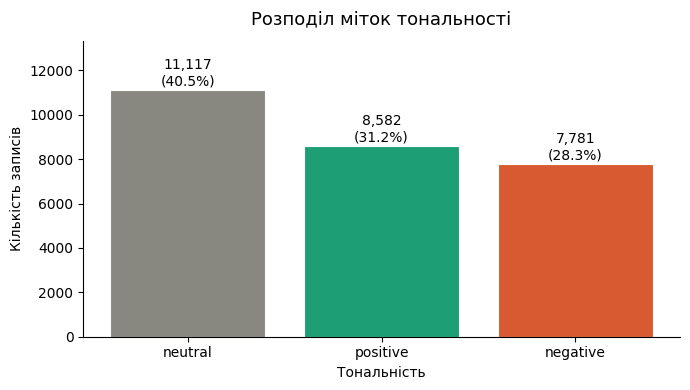

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

fig, ax = plt.subplots(figsize=(7, 4))
colors = {'neutral': '#888780', 'positive': '#1D9E75', 'negative': '#D85A30'}
bars = ax.bar(
    counts.index,
    counts.values,
    color=[colors[s] for s in counts.index],
    edgecolor='white', linewidth=0.8
)

# Підписи зі значенням і відсотком над кожним стовпчиком
for bar, (label, cnt) in zip(bars, counts.items()):
    pct = cnt / total * 100
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 80,
        f'{cnt:,}\n({pct:.1f}%)',
        ha='center', va='bottom', fontsize=10
    )

ax.set_title('Розподіл міток тональності', fontsize=13, pad=12)
ax.set_xlabel('Тональність')
ax.set_ylabel('Кількість записів')
ax.set_ylim(0, counts.max() * 1.2)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.tight_layout()
plt.show()

In [ ]:
df['text_len'] = df['text'].str.len()

In [ ]:
df['text_len'].describe()

,text_len
count,27480.000000
mean,68.330022
std,35.603870
min,3.000000
25%,39.000000
50%,64.000000
75%,97.000000
max,141.000000


/tmp/ipykernel_15394/4079843595.py:21: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


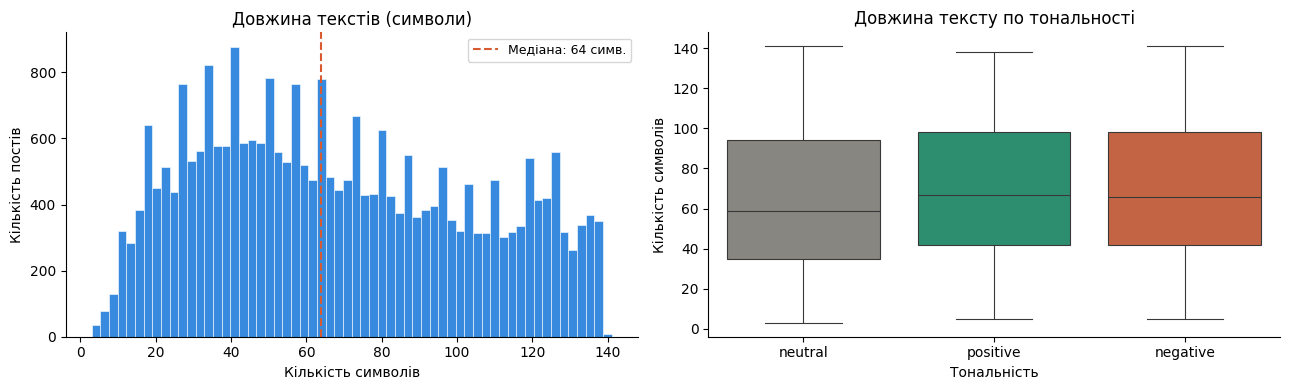

             count  mean   std  min   25%   50%   75%    max
sentiment                                                   
negative    7781.0  70.5  35.2  5.0  42.0  66.0  98.0  141.0
neutral    11117.0  65.2  36.4  3.0  35.0  59.0  94.0  141.0
positive    8582.0  70.4  34.6  5.0  42.0  67.0  98.0  138.0


In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# --- Загальна гістограма ---
axes[0].hist(
    df['text_len'], bins=60,
    color='#378ADD', edgecolor='white', linewidth=0.4
)
axes[0].axvline(df['text_len'].median(), color='#D85A30',
                linestyle='--', linewidth=1.5,
                label=f"Медіана: {df['text_len'].median():.0f} симв.")
axes[0].set_title('Довжина текстів (символи)')
axes[0].set_xlabel('Кількість символів')
axes[0].set_ylabel('Кількість постів')
axes[0].legend(fontsize=9)
axes[0].spines['top'].set_visible(False)
axes[0].spines['right'].set_visible(False)

# --- Boxplot по класах ---
color_map = {'neutral': '#888780', 'positive': '#1D9E75', 'negative': '#D85A30'}
order = ['neutral', 'positive', 'negative']
sns.boxplot(
    data=df, x='sentiment', y='text_len',
    order=order,
    palette=color_map,
    ax=axes[1], linewidth=0.8
)
axes[1].set_title('Довжина тексту по тональності')
axes[1].set_xlabel('Тональність')
axes[1].set_ylabel('Кількість символів')
axes[1].spines['top'].set_visible(False)
axes[1].spines['right'].set_visible(False)

plt.tight_layout()
plt.show()

# Базова статистика для висновку
print(df.groupby('sentiment')['text_len'].describe().round(1))

Найбільше постів в діапазоні 15-70 символів. Далі по спадаючій. По класам розподіл теж майже однаковий. Neutral / Positive / Negative : 40% / 31% / 28%

Візуалізацію мені робив Claude (я лише перечитувала код), бо мені самій поки туго дається ...)

### Завдання 3. Попередня обробка текстових даних та векторизація з bag of words


Наша задача тут отримати вектори методом bag of words колонки `text`, виконавши попередню обробку тексту.
Попередня обробка має включати
- видалення stopwords необхідної мови
- токенізація (розбиття текстів на фрагменти по 1 слову)
- стеммінг слів зі `SnowballStemmer`.
- самостійно задайте кількість слів в словнику для `sklearn.feature_extraction.text.CountVectorizer`. Можливо для цього доведеться виконати додатковий аналіз.

Ви також можете додати сюди додаткові методи очистки текстів, наприклад, видалення деяких символів чи груп символів, якщо в процесі роботи побачите, що хочете щось видалити.

Напишіть код аби виконати це завдання. Перед цим рекомендую детально ознайомитись з тим, що робить обʼєкт `sklearn.feature_extraction.text.CountVectorizer` за замовченням.

Це завдання можна виконати двома способами - один - максимально подібно до того, як ми це робили в лекції, другий - дещо інакше перегрупувавши етапи обробки тексту.




In [ ]:
from sklearn.feature_extraction.text import CountVectorizer
import nltk
from nltk.tokenize import word_tokenize

In [ ]:
nltk.download('punkt')
nltk.download('punkt_tab')

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.


True

In [ ]:
?CountVectorizer

In [ ]:
from nltk.tokenize import PunktSentenceTokenizer
from nltk.stem import SnowballStemmer
from nltk.corpus import stopwords

In [ ]:
nltk.download('stopwords')

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


True

In [ ]:
df['text'].iloc[1]

' Sooo SAD I will miss you here in San Diego!!!'

In [ ]:
word_tokenize(df['text'].iloc[1])

['Sooo',
 'SAD',
 'I',
 'will',
 'miss',
 'you',
 'here',
 'in',
 'San',
 'Diego',
 '!',
 '!',
 '!']

я хочу побачити всі знаки пунктуації в тексті і видалити повторювані.
Тому що бачу три знаки оклики сильно не підсвічують емоційність фрази як на мене і одного достатньо %%

In [ ]:
import string

# Дивимось які символи пунктуації є в текстах
all_punct = set()
for text in df['text']:
    for char in text:
        if char in string.punctuation:
            all_punct.add(char)

print("Знаки пунктуації в датасеті:")
print(sorted(all_punct))

Знаки пунктуації в датасеті:
['!', '#', '$', '%', '&', "'", '(', ')', '*', '+', ',', '-', '.', '/', ':', ';', '<', '=', '>', '?', '@', '[', '\\', ']', '^', '_', '`', '{', '|', '}', '~']


In [ ]:
stemmer = SnowballStemmer('english')

In [ ]:
english_stopwords = stopwords.words('english')
", ".join(english_stopwords)

"a, about, above, after, again, against, ain, all, am, an, and, any, are, aren, aren't, as, at, be, because, been, before, being, below, between, both, but, by, can, couldn, couldn't, d, did, didn, didn't, do, does, doesn, doesn't, doing, don, don't, down, during, each, few, for, from, further, had, hadn, hadn't, has, hasn, hasn't, have, haven, haven't, having, he, he'd, he'll, her, here, hers, herself, he's, him, himself, his, how, i, i'd, if, i'll, i'm, in, into, is, isn, isn't, it, it'd, it'll, it's, its, itself, i've, just, ll, m, ma, me, mightn, mightn't, more, most, mustn, mustn't, my, myself, needn, needn't, no, nor, not, now, o, of, off, on, once, only, or, other, our, ours, ourselves, out, over, own, re, s, same, shan, shan't, she, she'd, she'll, she's, should, shouldn, shouldn't, should've, so, some, such, t, than, that, that'll, the, their, theirs, them, themselves, then, there, these, they, they'd, they'll, they're, they've, this, those, through, to, too, under, until, up, 

In [ ]:
import re

def preprocess(text):
    # Видалення URL, згадок (@user), символів #, зайвих символів
    text = re.sub(r'http\S+', '', text)        # URLs
    text = re.sub(r'@\w+', '', text)           # @@param, @title, @markdown
    text = re.sub(r'[^a-zA-Z\s]', '', text)   # все окрім літер
    text = text.lower().strip()

    # Токенізація
    tokens = nltk.word_tokenize(text)

    # Видалення стоп-слів та стеммінг
    tokens = [stemmer.stem(t) for t in tokens if t not in english_stopwords]

    return ' '.join(tokens)

# Застосовуємо до всієї колонки
df['text_processed'] = df['text'].apply(preprocess)

# Перевіряємо результат
print(df['text'].iloc[1])
print(df['text_processed'].iloc[1])

 Sooo SAD I will miss you here in San Diego!!!
sooo sad miss san diego


всі знаки пунктуації вирішила видалити, тому що для bag to words вони не несуть ніякої цінності

In [ ]:
# Дивимось скільки унікальних слів є після обробки
cv_temp = CountVectorizer()
cv_temp.fit(df['text_processed'])
print(f'Розмір словника без обмежень: {len(cv_temp.vocabulary_)}')

# Дивимось розподіл частот слів
import numpy as np
X_temp = cv_temp.transform(df['text_processed'])
freq = np.asarray(X_temp.sum(axis=0)).flatten()
print(f'Слів, що зустрічаються > 10 разів: {(freq > 10).sum()}')
print(f'Слів, що зустрічаються > 50 разів: {(freq > 50).sum()}')
print(f'Слів, що зустрічаються > 100 разів: {(freq > 100).sum()}')

Розмір словника без обмежень: 21547
Слів, що зустрічаються > 10 разів: 2027
Слів, що зустрічаються > 50 разів: 597
Слів, що зустрічаються > 100 разів: 348


я взяла 1000 слів, тому що це між 10 та 50 разів. Найбільше повторюваних слів попаде в модель

In [ ]:
vectorizer_bow = CountVectorizer(max_features=1000)
X_bow = vectorizer_bow.fit_transform(df['text_processed'])

print(f'Розмір матриці: {X_bow.shape}')

Розмір матриці: (27480, 1000)


In [ ]:
X_bow[:10]

<Compressed Sparse Row sparse matrix of dtype 'int64'
	with 23 stored elements and shape (10, 1000)>

In [ ]:
df['text_processed'].values[5]

'shameless plug best ranger forum earth'

In [ ]:
X_bow[0].toarray()

array([[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
        0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
        0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
        0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
        0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
        0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
        0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
        0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
        0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
        0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
        0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
        0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
        0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
        0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 

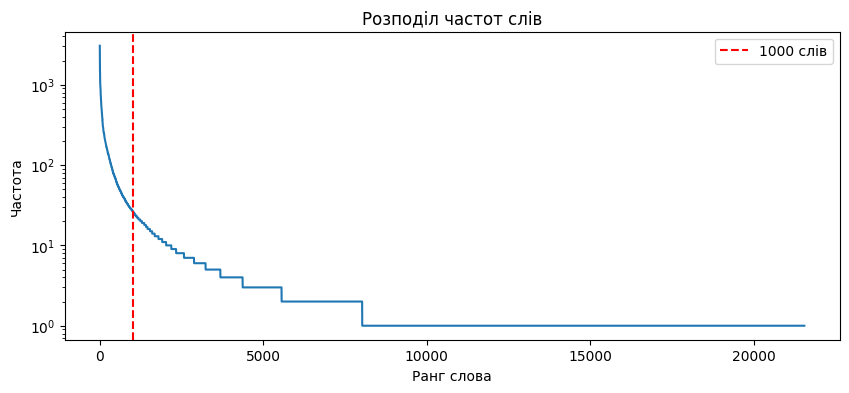

In [ ]:
# Сортуємо частоти за спаданням
freq_sorted = sorted(freq, reverse=True)

plt.figure(figsize=(10, 4))
plt.plot(freq_sorted)
plt.axvline(x=1000, color='red', linestyle='--', label='1000 слів')
plt.xlabel('Ранг слова')
plt.ylabel('Частота')
plt.title('Розподіл частот слів')
plt.legend()
plt.yscale('log')  # з логарифмічною шкалою краще видно хвіст
plt.show()

In [ ]:
# Найчастотніші слова
feature_names = vectorizer_bow.get_feature_names_out()
top_indices = freq[:1000].argsort()[::-1][:30]  # топ-30

print("Топ-30 найчастотніших слів у словнику:")
for i in top_indices:
    print(f"  {feature_names[i]:<15} {int(freq[i])} разів")

Топ-30 найчастотніших слів у словнику:
  serious         253 разів
  momma           251 разів
  mate            244 разів
  news            210 разів
  miley           196 разів
  coffe           190 разів
  wife            160 разів
  sooo            158 разів
  lose            148 разів
  soon            136 разів
  song            103 разів
  final           102 разів
  speak           92 разів
  beat            91 разів
  lucki           84 разів
  foot            80 разів
  call            73 разів
  upload          63 разів
  half            63 разів
  fish            62 разів
  shame           58 разів
  especi          57 разів
  stuff           54 разів
  id              54 разів
  garden          52 разів
  taken           52 разів
  connect         52 разів
  fantast         51 разів
  bill            50 разів
  thought         49 разів


слова sooo, що зустрічаються 158 разів та слово id, що зустрічається 54 разів - можливо потрібно видалити. Або залишаємо як є. sooo - додає тональності реченням. Але і  id зустрічається дуже мало. Залишаємо як є.

### Завдання 4. Побудова класифікатора

- Розділіть індекси даних на навчальний та тестовий набори в обраному співвівдношенні. Використовуючи отримані індекси сфомуйте набори для тренування класифікатора `X_train_bow, X_test_bow, y_train, y_test`.
- Навчіть класифікатор (наприклад, Logistic Regression, Decision Tree або один з алгоритмів бустингу) на даних, векторизованих методом bag-of-words. Спробуйте кілька моделей і оберіть найбільш точну :)
- Виведіть інформацію, яка дає можливість оцінити якість класифікації.
- Оцініть якість фінальної класифікації: вона хороша чи не дуже?



In [ ]:
X_bow.shape

(27480, 1000)

In [ ]:
from sklearn.model_selection import train_test_split

In [ ]:
X_train_bow, X_test_bow, y_train, y_test = train_test_split(X_bow, df['sentiment'], test_size=0.3, random_state=42, stratify=df['sentiment'])

In [ ]:
from sklearn.tree import DecisionTreeClassifier
from xgboost import XGBClassifier
from sklearn.metrics import classification_report
from sklearn.preprocessing import LabelEncoder

# XGBoost потребує числових міток
le = LabelEncoder()
y_train_enc = le.fit_transform(y_train)
y_test_enc = le.transform(y_test)

# Decision Tree
dt = DecisionTreeClassifier(random_state=42)
dt.fit(X_train_bow, y_train)
y_pred_dt = dt.predict(X_test_bow)
print("=== Decision Tree ===")
print(classification_report(y_test, y_pred_dt))

# XGBoost
xgb = XGBClassifier(random_state=42, eval_metric='mlogloss')
xgb.fit(X_train_bow, y_train_enc)
y_pred_xgb = le.inverse_transform(xgb.predict(X_test_bow))
print("=== XGBoost ===")
print(classification_report(y_test, y_pred_xgb))

=== Decision Tree ===
              precision    recall  f1-score   support

    negative       0.56      0.60      0.58      2334
     neutral       0.59      0.59      0.59      3335
    positive       0.68      0.66      0.67      2575

    accuracy                           0.61      8244
   macro avg       0.61      0.61      0.61      8244
weighted avg       0.61      0.61      0.61      8244

=== XGBoost ===
              precision    recall  f1-score   support

    negative       0.75      0.54      0.63      2334
     neutral       0.62      0.78      0.69      3335
    positive       0.77      0.70      0.73      2575

    accuracy                           0.69      8244
   macro avg       0.71      0.67      0.68      8244
weighted avg       0.70      0.69      0.69      8244



In [ ]:
from sklearn.linear_model import LogisticRegression

lr = LogisticRegression(max_iter=1000, random_state=42)
lr.fit(X_train_bow, y_train)
y_pred_lr = lr.predict(X_test_bow)
print("=== Logistic Regression ===")
print(classification_report(y_test, y_pred_lr))

=== Logistic Regression ===
              precision    recall  f1-score   support

    negative       0.70      0.59      0.64      2334
     neutral       0.63      0.73      0.68      3335
    positive       0.77      0.70      0.73      2575

    accuracy                           0.68      8244
   macro avg       0.70      0.68      0.68      8244
weighted avg       0.69      0.68      0.68      8244



Залишаю XGBoost. Трошечки вищий accuracy за логістичну регресію. Хоча всі три моделі порівняно не дуже якісно відпрацювали.

клас negative має найгірший f1-score у всих трьох моделях. Можливо через лексичне тональне забарвлення.

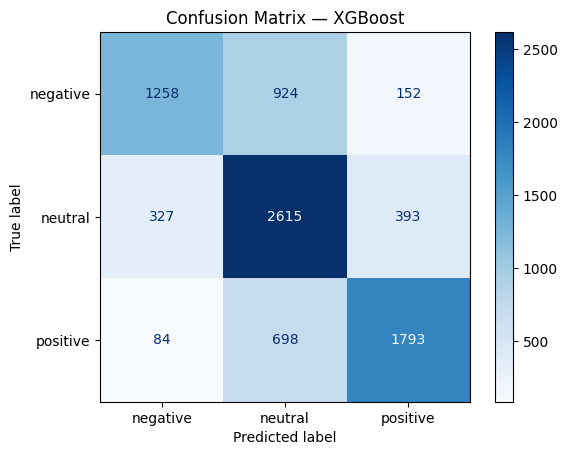

In [ ]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

cm = confusion_matrix(y_test, y_pred_xgb, labels=['negative', 'neutral', 'positive'])
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['negative', 'neutral', 'positive'])
disp.plot(cmap='Blues')
plt.title('Confusion Matrix — XGBoost')
plt.show()

Бачимо, що плутається нейтральний клас з негативним чи позитивним. Тому що щасто негативний відгук може наприклад бути написаний досить стримано чи завуальовано і межа між ними буде тонкою. Тому логічно, що тут найбільше помилок.

### Завдання 5. Аналіз впливовості слів в отриманого класифікатора

- Для обраної вами моделі проведіть аналіз важливості слів (ознак): які слова (токени) найбільше впливають для визначення сентименту? Чи це логічно на ваш погляд, що саме ці символи впливають найбільше/найменще?


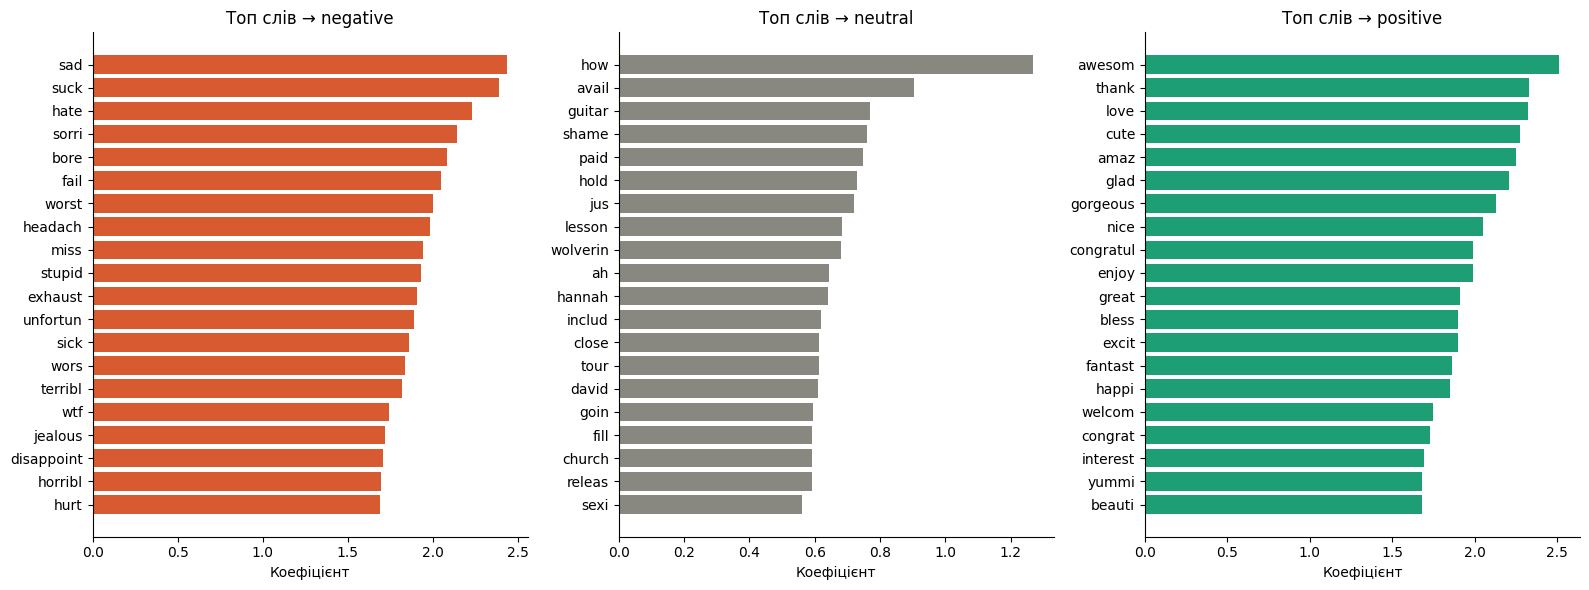

In [ ]:
feature_names = vectorizer_bow.get_feature_names_out()
n_top = 20

fig, axes = plt.subplots(1, 3, figsize=(16, 6))
classes = lr.classes_  # ['negative', 'neutral', 'positive']

for i, (cls, ax) in enumerate(zip(classes, axes)):
    coefs = pd.Series(lr.coef_[i], index=feature_names)

    # топ-15 найвпливовіших слів для цього класу
    top = coefs.nlargest(n_top)

    colors = ['#D85A30' if cls == 'negative'
              else '#888780' if cls == 'neutral'
              else '#1D9E75' for _ in top]

    ax.barh(top.index, top.values, color=colors)
    ax.set_title(f'Топ слів → {cls}', fontsize=12)
    ax.set_xlabel('Коефіцієнт')
    ax.invert_yaxis()
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.show()

Модель логіcтичної регресії дає коефіцієнти для кожного класу, тому для аналізу можна застосувати її. Вона на рівні з XGBoost.

Як на мене, слова за класами розділені логічно. Модель більше впевнена в позитивному та негативному каласах, ніж нейтральному. Через забарвленість слів. Це ми бачимо з коефіцієнтів.
Правда є деякі слова, що можуть мати подвійне сприйняття та розуміння. Як наприклад, слово miss в класі negative, яке має високу частоту повторюваності.

In [ ]:
# Скільки разів зустрічається miss і в яких реченнях
mask = df['text_processed'].str.contains(r'\bmiss\b', regex=True)

print(f"Кількість текстів зі словом 'miss': {mask.sum()}")
print()

# Дивимось оригінальний текст і клас
print(df[mask][['text', 'sentiment']].head(20))

# Скільки разів miss зустрічається в кожному класі
print( "\n" 'Скільки разів miss зустрічається в кожному класі')
counts = df[mask]['sentiment'].value_counts()
pcts = df[mask]['sentiment'].value_counts(normalize=True).mul(100).round(1)
print(pd.DataFrame({'count': counts, '%': pcts}))

Кількість текстів зі словом 'miss': 938

                                                  text sentiment
1        Sooo SAD I will miss you here in San Diego!!!  negative
18          is back home now      gonna miss every one  negative
36   Born and raised in NYC and living in Texas for...  negative
87   His snoring is so annoying n it keeps me from ...   neutral
88   i miss you bby      wish you were going tomorr...  negative
139  missed all the awesome weather, because she wa...  negative
176   I miss my neice  can`t wait to see her bad n ...  negative
183         I`m sad that I missed you guys last night!  negative
196  im soo bored...im deffo missing my music channels  negative
213   We never miss ICarly - my son has a huge crus...  positive
290  Going to miss my roomie ... We will no longer ...  negative
306          Dinner with the fam... I have missed them  negative
324   Not sure it didn`t say it was 2 big. I jst sa...   neutral
334                             I Miss Daddy and 

Бачимо, що слово miss більше зустрічається в негативному класі і тому з цим словом бачимо що модель "помиляється" 30%.

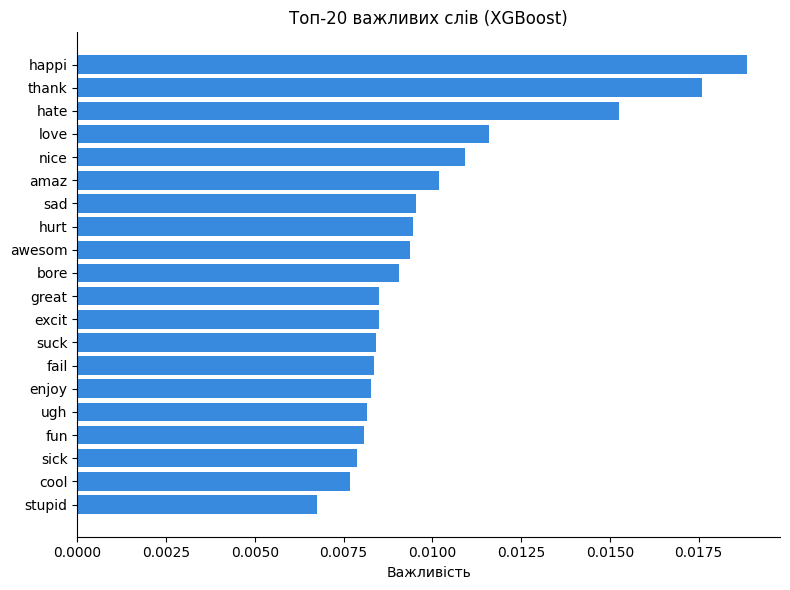

In [ ]:
#Тепер хочу з XGBoost визначити важливість слів
feature_names = vectorizer_bow.get_feature_names_out()

# Отримуємо важливості
importances = pd.Series(xgb.feature_importances_, index=feature_names)
top20 = importances.nlargest(20)

plt.figure(figsize=(8, 6))
plt.barh(top20.index, top20.values, color='#378ADD')
plt.title('Топ-20 важливих слів (XGBoost)', fontsize=12)
plt.xlabel('Важливість')
plt.gca().invert_yaxis()
plt.gca().spines['top'].set_visible(False)
plt.gca().spines['right'].set_visible(False)
plt.tight_layout()
plt.show()

XGBoost показує змішаний список — тут є і positive і negative слова разом, бо важливість загальна без розбивки по класах.

LR показує окремо для кожного класу — тому є більш інформативною для аналізу

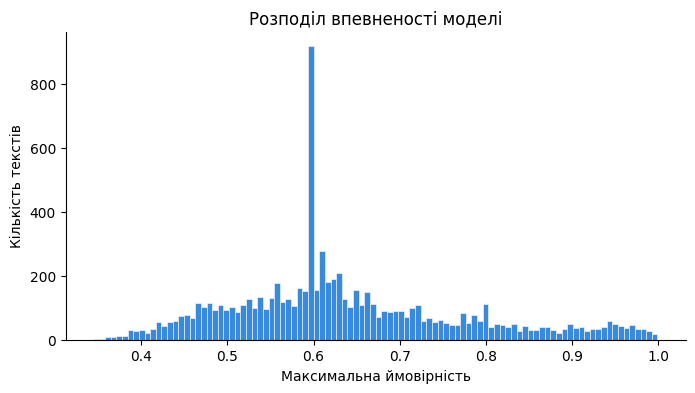

In [ ]:
# Отримуємо ймовірності для тестової вибірки
proba = xgb.predict_proba(X_test_bow)

# proba — масив з 3 колонками (negative, neutral, positive)
# беремо максимальну ймовірність для кожного тексту
max_proba = proba.max(axis=1)

# Будуємо гістограму
plt.figure(figsize=(8, 4))
plt.hist(max_proba, bins=100, color='#378ADD', edgecolor='white', linewidth=0.4)
plt.xlabel('Максимальна ймовірність')
plt.ylabel('Кількість текстів')
plt.title('Розподіл впевненості моделі')
plt.gca().spines['top'].set_visible(False)
plt.gca().spines['right'].set_visible(False)
plt.show()

Модель більше впевнена, ніж ні.

### Завдання 6. Векторизація текстів з допомогою TF-IDF. Тренування класифікатора, аналіз точності і впливовості слів.

- Проведіть векторизацію текстів з векторизатором TfidfVectorizer. Реалізуйте векторизацію так, аби препроцесинг включав всі ті самі кроки, що і в випадку використання векторизації Bag of Words.

- Натренуйте той самий класифікатор на TF-IDF векторах, виконавши розбивку набору даних на train, test так, аби в трейні були всі ті самі записи, що і були в попередньому завданні (це важливо для порівняння результатів).

- Проаналізуйте якість класифікації вивівши потрібні для цього метрики. Чи стала якість класифікації кращою?

- Які токени найбільше впливають на результат при тренуваннні класифікатора з TF-IDF векторами? Порівняйте з найважливішими токенами при Bag of Words векторизації. Яку векторизацію ви б обрали для фінальної імплементації рішення? Обґрунтуйте свій вибір.



In [ ]:
from sklearn.feature_extraction.text import TfidfVectorizer

vactorizer_tfidf = TfidfVectorizer(max_features=1000)
X_tfidf = vactorizer_tfidf.fit_transform(df['text_processed'])

In [ ]:
# Створюємо позиційні індекси (0, 1, 2, ... 27480)
positional_indices = np.arange(X_bow.shape[0])

idx_train, idx_test = train_test_split(
    positional_indices,
    test_size=0.3,
    random_state=42,
    stratify=df['sentiment']
)

# BoW
X_train_bow = X_bow[idx_train]
X_test_bow = X_bow[idx_test]

# TF-IDF — ті самі індекси
X_train_tfidf = X_tfidf[idx_train]
X_test_tfidf = X_tfidf[idx_test]

y_train = df['sentiment'].iloc[idx_train]
y_test = df['sentiment'].iloc[idx_test]

print(f'Train: {X_train_bow.shape}, Test: {X_test_bow.shape}')

Train: (19236, 1000), Test: (8244, 1000)


In [ ]:
# Перенавчаємо на BoW з новими індексами
y_train_enc = le.fit_transform(y_train)
y_test_enc = le.transform(y_test)

xgb_bow = XGBClassifier(random_state=42, eval_metric='mlogloss')
xgb_bow.fit(X_train_bow, y_train_enc)
y_pred_bow = le.inverse_transform(xgb_bow.predict(X_test_bow))

print("=== XGBoost + BoW ===")
print(classification_report(y_test, y_pred_bow))

# Навчаємо на TF-IDF
xgb_tfidf = XGBClassifier(random_state=42, eval_metric='mlogloss')
xgb_tfidf.fit(X_train_tfidf, y_train_enc)
y_pred_tfidf = le.inverse_transform(xgb_tfidf.predict(X_test_tfidf))

print("=== XGBoost + TF-IDF ===")
print(classification_report(y_test, y_pred_tfidf))

=== XGBoost + BoW ===
              precision    recall  f1-score   support

    negative       0.75      0.54      0.63      2334
     neutral       0.62      0.78      0.69      3335
    positive       0.77      0.70      0.73      2575

    accuracy                           0.69      8244
   macro avg       0.71      0.67      0.68      8244
weighted avg       0.70      0.69      0.69      8244

=== XGBoost + TF-IDF ===
              precision    recall  f1-score   support

    negative       0.75      0.53      0.62      2334
     neutral       0.61      0.78      0.69      3335
    positive       0.77      0.69      0.73      2575

    accuracy                           0.68      8244
   macro avg       0.71      0.67      0.68      8244
weighted avg       0.70      0.68      0.68      8244



Для фінальної імплементації рішення я б обрала Bag of Words векторизацію.
F-score 0.69 . Хоча загалом обидві векторизації дають однаковий результат з різницею в 1%.

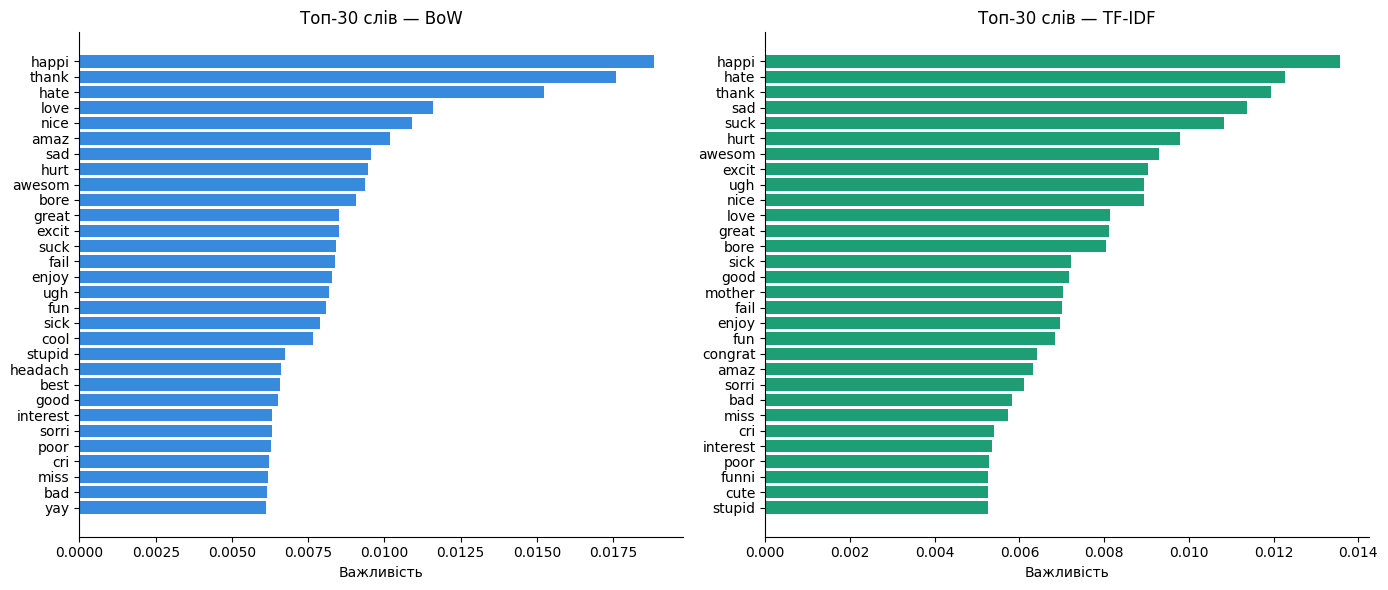

In [ ]:
vectorizer_tfidf = TfidfVectorizer(max_features=1000)
X_tfidf = vectorizer_tfidf.fit_transform(df['text_processed'])

feature_names_tfidf = vectorizer_tfidf.get_feature_names_out()
importances_tfidf = pd.Series(xgb_tfidf.feature_importances_, index=feature_names_tfidf)

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# BoW
top_bow = importances.nlargest(30)
axes[0].barh(top_bow.index, top_bow.values, color='#378ADD')
axes[0].set_title('Топ-30 слів — BoW')
axes[0].set_xlabel('Важливість')
axes[0].invert_yaxis()
axes[0].spines['top'].set_visible(False)
axes[0].spines['right'].set_visible(False)

# TF-IDF
top_tfidf = importances_tfidf.nlargest(30)
axes[1].barh(top_tfidf.index, top_tfidf.values, color='#1D9E75')
axes[1].set_title('Топ-30 слів — TF-IDF')
axes[1].set_xlabel('Важливість')
axes[1].invert_yaxis()
axes[1].spines['top'].set_visible(False)
axes[1].spines['right'].set_visible(False)

plt.tight_layout()
plt.show()

Але, як на мене, Bag of Words визначає краще важливість слів в твітах для віднесення їх до класу.

### Завдання 7. Аналіз помилок класифікації з векторизацією TF-IDF.

- Проаналізуйте, на яких екземплярах помиляється класифікатор при векторизації TF-IDF.
- На основі аналізу запропонуйте 3 шляхи поліпшення якості класифікації.

In [ ]:
# Створюємо датафрейм з помилками
errors_df = df.iloc[idx_test].copy()
errors_df['predicted'] = y_pred_tfidf

# Залишаємо лише помилкові передбачення
errors_df = errors_df[errors_df['sentiment'] != errors_df['predicted']]

print(f'Всього помилок: {len(errors_df)}')
print(f'Відсоток помилок: {len(errors_df)/len(idx_test)*100:.1f}%')
print()
print(errors_df.groupby(['sentiment', 'predicted']).size())

Всього помилок: 2617
Відсоток помилок: 31.7%

sentiment  predicted
negative   neutral      951
           positive     139
neutral    negative     331
           positive     388
positive   negative      79
           neutral      729
dtype: int64


In [ ]:
# negative передбачено як neutral
mask = (errors_df['sentiment'] == 'negative') & (errors_df['predicted'] == 'neutral')
print("=== negative → neutral ===")
print(errors_df[mask][['text', 'sentiment', 'predicted']].head(7).to_string())

# positive передбачено як neutral
mask = (errors_df['sentiment'] == 'positive') & (errors_df['predicted'] == 'neutral')
print("\n=== positive → neutral ===")
print(errors_df[mask][['text', 'sentiment', 'predicted']].head(7).to_string())

# neutral передбачено як negative
mask = (errors_df['sentiment'] == 'neutral') & (errors_df['predicted'] == 'negative')
print("\n=== neutral → negative ===")
print(errors_df[mask][['text', 'sentiment', 'predicted']].head(7).to_string())

=== negative → neutral ===
                                                                                                                              text sentiment predicted
2664                                                         wearing a pair of trousers that were loose last year, tight this year  negative   neutral
26543                                                                         Time to get ready for wrk! Ahhhh, I dnt wanna goooo!  negative   neutral
6883                                                                      is wondering y Mother Nature is making my life miserable  negative   neutral
13043                                                             i have three hours to do my hair. and it STILL won`t be straight  negative   neutral
5865                   I assume you mean 2nd item with 3 nested lines, but no invert call tree button to be found   ï¿½  ï¿½   ï¿½  negative   neutral
26734   My husband is loosing his GOVERMENT job due to downsizing-h

Як я раніше вже описувала, модель не вловлює найбільше негативних речень і відносить їх до нейтральних. Така сама майже ситуація і з позитивними. Є речення де зустрічаються і негативні слова і позитивні.

In [ ]:
df.loc[14754]['text']

' a buff guy.....unfortunatly alot of people dont know Danny`s name either which is sad   Sophie is so sweet'

In [ ]:
print('unfortun' in feature_names)
print([w for w in feature_names if 'unfortun' in w])

True
['unfortun']


In [ ]:
# Чи є слова в словнику
words = ['know', 'peopl', 'name']
for w in words:
    print(f'{w}: {w in feature_names}')

know: True
peopl: True
name: True


In [ ]:
# Скільки разів зустрічаються в датасеті
for w in words:
    mask = df['text_processed'].str.contains(rf'\b{w}\b', regex=True)
    print(f'{w}: {mask.sum()} текстів')
    print(df[mask]['sentiment'].value_counts())
    print()

know: 943 текстів
sentiment
neutral     417
negative    271
positive    255
Name: count, dtype: int64

peopl: 366 текстів
sentiment
neutral     141
negative    126
positive     99
Name: count, dtype: int64

name: 112 текстів
sentiment
neutral     49
positive    41
negative    22
Name: count, dtype: int64



Ось в цьому рядочку зустрічаються слова 'sad' , 'sweet'. Ці два слова з різних класів негативного та позитивного. Саме речення належить до нейтрального класу, але модель передбачає його в негативному. Можливо, тому що слово unfortunatly теж є в словнику (якщо модель визначає по більшій кількості слів зі словника). Або ж модель віднесла його до негативного тому що слово unfortunatly та sad в реченні зустрічається перед sweet. Можливо логіка така.
Хоча слова зі словника know, people, name відносяться до нейтрального класу і стоять після unfortunatly. Якщо відносити речення до відповідного класу по переважній більшості слів з відповідного класу, то модель мала б передбачити його в нейтральному класі. Але модель передбачає скоріш по вазі значимості слова. Тому слово sad перемогло саме по значимості. Я так вважаю.

Для покращення роботи моделі я б зробила інший стеммінг. Можливо потрібно надати більшої тоальності словам. Я не знаю тільки як, поки що...

Можливо потрібно розширити словник. Хоча не думаю що це допоможе , тому що з нашого датасету, як на мене ми взяли максимум вживаних слів. Але все ж перевірити потрібно.

Як на мене, то і модель XGBoost з BoW не сильні в такому передбаченні.

In [ ]:
# Створюємо зручну таблицю слово → вага для конкретного тексту
text_idx = 14754  # індекс тексту

# Знаходимо позицію тексту в матриці
positional_idx = df.index.get_loc(text_idx)

# Отримуємо вектор TF-IDF для цього тексту
tfidf_vector = X_tfidf[positional_idx]

# Перетворюємо в зручний формат
feature_names_tfidf = vectorizer_tfidf.get_feature_names_out()
tfidf_scores = pd.Series(
    tfidf_vector.toarray().flatten(),
    index=feature_names_tfidf
)

# Показуємо лише слова з ненульовою вагою
print(tfidf_scores[tfidf_scores > 0].sort_values(ascending=False))

alot      0.460590
either    0.405194
name      0.390170
sweet     0.387062
peopl     0.319394
sad       0.296974
know      0.262630
dont      0.249888
dtype: float64


In [ ]:
# Порівняння BoW vs TF-IDF ваг
comparison = pd.DataFrame({
    'bow_freq': pd.Series(np.asarray(X_bow.mean(axis=0)).flatten(),
                          index=vectorizer_bow.get_feature_names_out()),
    'tfidf_weight': mean_tfidf
})

# Слова де TF-IDF вага висока але BoW частота низька — це унікальні слова
comparison['ratio'] = comparison['tfidf_weight'] / comparison['bow_freq']
print(comparison.nlargest(20, 'tfidf_weight'))

       bow_freq  tfidf_weight     ratio
im     0.111317      0.027768  0.249450
day    0.087846      0.024388  0.277625
go     0.085990      0.023721  0.275858
get    0.069469      0.018707  0.269281
good   0.057096      0.018003  0.315308
work   0.053967      0.017794  0.329721
love   0.053057      0.017299  0.326039
like   0.052911      0.015824  0.299073
thank  0.035007      0.014528  0.415010
got    0.045124      0.013816  0.306190
dont   0.043741      0.013735  0.314009
miss   0.034971      0.013519  0.386573
happi  0.036135      0.013024  0.360411
today  0.040575      0.012901  0.317944
time   0.039265      0.012676  0.322836
want   0.035771      0.012612  0.352582
one    0.038392      0.012304  0.320487
know   0.035262      0.011933  0.338405
cant   0.037482      0.011912  0.317814
lol    0.034680      0.011802  0.340306


З ваги слів логічно було б віднести речення до нейтрального чи позитивного класу. Але TF-IDF показує вагу кожного слова з тієї позиції, що високі значення означають, що слово є важливим для цього речення і одночасно зустрічається в інших реченнях дуже рідко.
Середня TF-IDF вага кожного слова по всьому датасету взагалі не дає ніякої інформації.

А, в нас задача правильно розподілити речення за класом, а не змагання твітів між собою.

Тому залишаю XGBoost з BoW.

І пропоную покращити :
інший стеммінг

розширити словник

надати тональності словам

застосувати іншу модель

І на фінал кернел для натхнення і ознайомлення з рішенням оригінальної задачі. Багато цікавих візуалізацій і аналізу є тут, а також тут розвʼязується саме проблема named entitty recognition і можна ознайомитись як це робиться - вона дещо складніша по своїй суті ніж класифікація, подумайте, чому:

https://www.kaggle.com/code/tanulsingh077/twitter-sentiment-extaction-analysis-eda-and-model